# **the next code does:**

- Loads the **best trained model checkpoint** and the saved class mapping.
- Combines the training and validation images into one dataset for final training.
- Checks that the **Neysan test images are completely separate** from the training images.
- Saves the combined dataset information and shows the number of images in each class.

In [1]:
from pathlib import Path
import pandas as pd
import torch

PROJECT_ROOT = Path(
    r"D:\Maktab_Sharif_Projects\traffic-vehicle-classification"
)

MANIFEST_DIR = (
    PROJECT_ROOT / "data" / "neysan_experiment" / "manifests"
)
EXPERIMENT_DIR = PROJECT_ROOT / "outputs" / "neysan_experiment"
FINAL_DIR = EXPERIMENT_DIR / "trainval_refit"
FINAL_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cpu")
START_PATH = EXPERIMENT_DIR / "resnet18_neysan_best.pt"

starting = torch.load(
    START_PATH,
    map_location="cpu",
    weights_only=True,
)

class_to_idx = starting["class_to_idx"]
classes = sorted(class_to_idx, key=class_to_idx.get)

train_df = pd.read_csv(MANIFEST_DIR / "train.csv")
val_df = pd.read_csv(MANIFEST_DIR / "validation.csv")
neysan_df = pd.read_csv(MANIFEST_DIR / "neysan_test.csv")

combined_df = pd.concat(
    [train_df, val_df], ignore_index=True
)

assert combined_df["path"].is_unique
assert combined_df["sha256"].is_unique
assert set(combined_df["label"]) == set(classes)
assert "neysan" not in classes
assert set(combined_df["sha256"]).isdisjoint(
    neysan_df["sha256"]
)

missing_paths = [
    path for path in combined_df["path"]
    if not Path(path).is_file()
]
assert not missing_paths, f"Missing images: {missing_paths[:5]}"

combined_df.to_csv(
    FINAL_DIR / "train_validation_manifest.csv",
    index=False,
)

print("Starting checkpoint epoch:", starting["epoch"])
print("Combined training images:", len(combined_df))
print("Reserved Neysan images:", len(neysan_df))
print("Exact overlap: 0")

display(
    combined_df.groupby("label")
    .size()
    .rename("training_images")
    .to_frame()
)

Starting checkpoint epoch: 26
Combined training images: 3269
Reserved Neysan images: 243
Exact overlap: 0


,training_images
label,
ambulance,408
autobus,520
kamyun,437
kamyunet,614
minibus,434
savari,352
taxi,348
vanet,156


# **the next code does:**

- Sets the final training stage to **10 additional epochs** using the combined train + validation data.
- Takes the learning rates from the best checkpoint and uses a **fresh AdamW optimizer**.
- Disables the scheduler because there is **no validation set** during this final training.
- Saves the complete final training configuration as a **JSON recipe**.

In [4]:
import copy
import json

FINAL_EPOCHS = 10

saved_groups = starting["optimizer_state_dict"]["param_groups"]
assert len(saved_groups) == 3

FINAL_CONFIG = copy.deepcopy(starting["config"])

FINAL_CONFIG.update({
    "initialization": "selected_checkpoint",
    "starting_checkpoint": START_PATH.name,
    "starting_checkpoint_epoch": starting["epoch"],
    "stage": "train_validation_refit",
    "epochs": FINAL_EPOCHS,
    "optimizer_state": "fresh",
    "layer3_lr": float(saved_groups[0]["lr"]),
    "layer4_lr": float(saved_groups[1]["lr"]),
    "fc_lr": float(saved_groups[2]["lr"]),
    "scheduler": "none_fixed_learning_rates",
    "scheduler_monitor": None,
    "training_images": len(combined_df),
    "validation_images": 0,
    "checkpoint_rule": "save_after_final_epoch",
})

recipe_path = FINAL_DIR / "final_training_recipe.json"

with recipe_path.open("w", encoding="utf-8") as file:
    json.dump(FINAL_CONFIG, file, indent=2)

print("Additional epochs:", FINAL_EPOCHS)
print("Training images:", FINAL_CONFIG["training_images"])
print("Sampling:", FINAL_CONFIG["sampling"])
print("Dropout:", FINAL_CONFIG["dropout"])
print("Loss:", FINAL_CONFIG["loss"])
print("Optimizer: fresh AdamW")
print("Layer 3 fixed learning rate:", FINAL_CONFIG["layer3_lr"])
print("Layer 4 fixed learning rate:", FINAL_CONFIG["layer4_lr"])
print("FC fixed learning rate:", FINAL_CONFIG["fc_lr"])
print("Checkpoint rule: save after epoch 10")
print("Recipe saved:", recipe_path)

Additional epochs: 10
Training images: 3269
Sampling: balanced
Dropout: 0.25
Loss: bce
Optimizer: fresh AdamW
Layer 3 fixed learning rate: 9.375e-08
Layer 4 fixed learning rate: 3.125e-07
FC fixed learning rate: 3.125e-05
Checkpoint rule: save after epoch 10
Recipe saved: D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\neysan_experiment\trainval_refit\final_training_recipe.json


In [5]:
with recipe_path.open("r", encoding="utf-8") as file:
    saved_recipe = json.load(file)

assert FINAL_EPOCHS == 10
assert saved_recipe["epochs"] == FINAL_EPOCHS
assert saved_recipe["checkpoint_rule"] == "save_after_final_epoch"

print("Verified additional epochs:", saved_recipe["epochs"])
print(f"Final checkpoint will be saved after epoch {FINAL_EPOCHS}.")

Verified additional epochs: 10
Final checkpoint will be saved after epoch 10.


# **the next code does:**

- Creates the final training dataset using the same **augmentation and normalization** as before.
- Builds balanced batches with **2 images from each of the 8 classes = 16 images per batch**.
- Combines all training and validation images and prepares them for the final training stage.
- Creates the final DataLoader and prints the number of images and batches.

In [6]:
import math
import random
import numpy as np

from PIL import Image, ImageOps
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, Sampler

SEED = FINAL_CONFIG["seed"]
BATCH_SIZE = FINAL_CONFIG["batch_size"]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


class ResizeWithPadding:
    def __init__(self, size, color):
        self.size = size
        self.color = tuple(color)

    def __call__(self, image):
        resized = ImageOps.contain(
            image,
            (self.size, self.size),
            method=Image.Resampling.BILINEAR,
        )

        canvas = Image.new(
            "RGB", (self.size, self.size), self.color
        )
        canvas.paste(
            resized,
            (
                (self.size - resized.width) // 2,
                (self.size - resized.height) // 2,
            ),
        )
        return canvas


final_train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(
        p=FINAL_CONFIG["horizontal_flip_probability"]
    ),
    transforms.ColorJitter(**FINAL_CONFIG["color_jitter"]),
    ResizeWithPadding(
        FINAL_CONFIG["image_size"],
        FINAL_CONFIG["padding_color"],
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        FINAL_CONFIG["mean"],
        FINAL_CONFIG["std"],
    ),
])


class FinalVehicleDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        with Image.open(row["path"]) as image:
            image = ImageOps.exif_transpose(image).convert("RGB")
            tensor = self.transform(image)

        return tensor, class_to_idx[row["label"]]


class BalancedBatchSampler(Sampler):
    def __init__(self, labels, batches_per_epoch, seed):
        labels = np.asarray(labels)
        self.classes = sorted(np.unique(labels))
        self.indices = {
            label: np.flatnonzero(labels == label)
            for label in self.classes
        }
        self.batches_per_epoch = batches_per_epoch
        self.seed = seed
        self.epoch = 0

        assert all(len(indices) >= 2 for indices in self.indices.values())

    def __len__(self):
        return self.batches_per_epoch

    def __iter__(self):
        rng = np.random.default_rng(self.seed + self.epoch)
        self.epoch += 1

        pools = {
            label: rng.permutation(indices)
            for label, indices in self.indices.items()
        }
        positions = {label: 0 for label in self.classes}

        for _ in range(self.batches_per_epoch):
            batch = []

            for label in self.classes:
                selected = []

                while len(selected) < 2:
                    start = positions[label]
                    take = min(
                        2 - len(selected),
                        len(pools[label]) - start,
                    )
                    selected.extend(
                        pools[label][start:start + take].tolist()
                    )
                    positions[label] += take

                    if positions[label] == len(pools[label]):
                        pools[label] = rng.permutation(
                            self.indices[label]
                        )
                        positions[label] = 0

                batch.extend(selected)

            rng.shuffle(batch)
            yield batch


assert BATCH_SIZE == 2 * len(classes)

final_dataset = FinalVehicleDataset(
    combined_df, final_train_transform
)

final_sampler = BalancedBatchSampler(
    labels=combined_df["label"].to_numpy(),
    batches_per_epoch=math.ceil(len(final_dataset) / BATCH_SIZE),
    seed=SEED,
)

final_generator = torch.Generator().manual_seed(SEED)

final_loader = DataLoader(
    final_dataset,
    batch_sampler=final_sampler,
    num_workers=0,
    generator=final_generator,
)

print("Unique training images:", len(final_dataset))
print("Batches per epoch:", len(final_loader))
print("Image draws per epoch:", len(final_loader) * BATCH_SIZE)
print("Balanced batch: 8 classes × 2 images = 16")
print("Augmentation: preserved")
print("Final training loader ready.")

Unique training images: 3269
Batches per epoch: 205
Image draws per epoch: 3280
Balanced batch: 8 classes × 2 images = 16
Augmentation: preserved
Final training loader ready.


# **the next code does:**

- Creates a new **ResNet18** and loads the weights from the previously selected best checkpoint.
- Freezes most layers and keeps only **layer3, layer4, and the classifier** trainable.
- Creates a fresh **AdamW optimizer** and **BCEWithLogitsLoss** for the final training.
- Sets the model to use the same training settings while keeping **BatchNorm statistics fixed**.

In [ ]:
from torch import nn
import torch.nn.functional as F
from torchvision import models

final_model = models.resnet18(weights=None)

final_model.fc = nn.Sequential(
    nn.Dropout(p=FINAL_CONFIG["dropout"]),
    nn.Linear(final_model.fc.in_features, len(classes)),
)

final_model.load_state_dict(starting["model_state_dict"])

for parameter in final_model.parameters():
    parameter.requires_grad = False

for layer_name in FINAL_CONFIG["trainable_layers"]:
    for parameter in getattr(final_model, layer_name).parameters():
        parameter.requires_grad = True

final_model = final_model.to(DEVICE)

final_optimizer = torch.optim.AdamW(
    [
        {
            "params": final_model.layer3.parameters(),
            "lr": FINAL_CONFIG["layer3_lr"],
        },
        {
            "params": final_model.layer4.parameters(),
            "lr": FINAL_CONFIG["layer4_lr"],
        },
        {
            "params": final_model.fc.parameters(),
            "lr": FINAL_CONFIG["fc_lr"],
        },
    ],
    weight_decay=FINAL_CONFIG["weight_decay"],
)

final_criterion = nn.BCEWithLogitsLoss()


def final_classification_loss(logits, labels):
    targets = F.one_hot(
        labels, num_classes=len(classes)
    ).to(dtype=logits.dtype)

    return final_criterion(logits, targets)


def set_final_training_mode():
    final_model.eval()

    for layer_name in FINAL_CONFIG["trainable_layers"]:
        getattr(final_model, layer_name).train()

    for module in final_model.modules():
        if isinstance(module, nn.modules.batchnorm._BatchNorm):
            module.eval()


trainable_parameters = sum(
    parameter.numel()
    for parameter in final_model.parameters()
    if parameter.requires_grad
)

print("Starting checkpoint:", START_PATH.name)
print("Starting checkpoint epoch:", starting["epoch"])
print("Trainable parameters:", trainable_parameters)
print("Dropout:", FINAL_CONFIG["dropout"])
print("Loss: BCEWithLogitsLoss")
print("Optimizer: fresh AdamW")
print("Additional epochs:", FINAL_EPOCHS)

for name, group in zip(
    ["Layer 3", "Layer 4", "FC"],
    final_optimizer.param_groups,
):
    print(f"{name} fixed learning rate: {group['lr']}")

Starting checkpoint: resnet18_neysan_best.pt
Starting checkpoint epoch: 26
Trainable parameters: 10497544
Dropout: 0.25
Loss: BCEWithLogitsLoss
Optimizer: fresh AdamW
Additional epochs: 10
Layer 3 fixed learning rate: 9.375e-08
Layer 4 fixed learning rate: 3.125e-07
FC fixed learning rate: 3.125e-05


# **the next code does:**

- Trains the final ResNet18 for **10 additional epochs** using all training + validation images.
- Records the **loss, accuracy, learning rates, and training time** after each epoch.
- Saves a recovery checkpoint and training history after every epoch.
- After training finishes, saves the **final model checkpoint** for testing on the reserved Neysan images.

In [8]:
import copy
import time

FINAL_PATH = FINAL_DIR / "resnet18_neysan_trainval_final.pt"
RECOVERY_PATH = FINAL_DIR / "resnet18_neysan_trainval_latest.pt"
FINAL_HISTORY_PATH = FINAL_DIR / "final_training_history.csv"


def save_atomic(checkpoint, path):
    temporary_path = path.with_suffix(".tmp")
    torch.save(checkpoint, temporary_path)
    temporary_path.replace(path)


def train_final_model():
    for path in [FINAL_PATH, RECOVERY_PATH, FINAL_HISTORY_PATH]:
        if path.exists():
            raise FileExistsError(
                f"Existing output: {path}\n"
                "Preserve or move existing results before a new run."
            )

    assert FINAL_EPOCHS == FINAL_CONFIG["epochs"]

    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    final_sampler.epoch = 0
    final_generator.manual_seed(SEED)

    training_hashes = sorted(
        combined_df["sha256"].astype(str).tolist()
    )
    history = []

    for epoch in range(1, FINAL_EPOCHS + 1):
        started = time.perf_counter()
        set_final_training_mode()

        total_loss = 0.0
        total_correct = 0
        total_count = 0

        for images, labels in final_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            final_optimizer.zero_grad(set_to_none=True)

            logits = final_model(images)
            loss = final_classification_loss(logits, labels)

            if not torch.isfinite(loss):
                raise RuntimeError(
                    f"Non-finite loss at epoch {epoch}."
                )

            loss.backward()
            final_optimizer.step()

            count = labels.size(0)
            total_loss += loss.item() * count
            total_correct += (
                logits.argmax(1) == labels
            ).sum().item()
            total_count += count

        row = {
            "epoch": epoch,
            "train_loss": total_loss / total_count,
            "train_accuracy": total_correct / total_count,
            "image_draws": total_count,
            "layer3_lr": final_optimizer.param_groups[0]["lr"],
            "layer4_lr": final_optimizer.param_groups[1]["lr"],
            "fc_lr": final_optimizer.param_groups[2]["lr"],
            "seconds": time.perf_counter() - started,
        }
        history.append(row)

        checkpoint = {
            "epoch": epoch,
            "stage": "neysan_train_validation_refit",
            "model_state_dict": final_model.state_dict(),
            "optimizer_state_dict": final_optimizer.state_dict(),
            "class_to_idx": dict(class_to_idx),
            "config": copy.deepcopy(FINAL_CONFIG),
            "training_sha256": training_hashes,
            "training_metrics": dict(row),
        }

        save_atomic(checkpoint, RECOVERY_PATH)

        history_df = pd.DataFrame(history)
        temporary_history = FINAL_HISTORY_PATH.with_suffix(".tmp")
        history_df.to_csv(temporary_history, index=False)
        temporary_history.replace(FINAL_HISTORY_PATH)

        print(
            f"Epoch {epoch:02d}/{FINAL_EPOCHS} | "
            f"Train loss: {row['train_loss']:.6f} | "
            f"Train accuracy: {row['train_accuracy']:.2%} | "
            f"{row['seconds']:.1f}s",
            flush=True,
        )

    final_model.eval()
    save_atomic(checkpoint, FINAL_PATH)

    print("\nTrain + validation refit completed.")
    print("Final checkpoint:", FINAL_PATH)
    print("History saved:", FINAL_HISTORY_PATH)

    return pd.DataFrame(history)


print("Final training loop ready.")
print("Fixed additional epochs:", FINAL_EPOCHS)

Final training loop ready.
Fixed additional epochs: 10


In [9]:
final_history = train_final_model()

Epoch 01/10 | Train loss: 0.010207 | Train accuracy: 99.30% | 417.5s
Epoch 02/10 | Train loss: 0.009717 | Train accuracy: 99.36% | 448.2s
Epoch 03/10 | Train loss: 0.008464 | Train accuracy: 99.39% | 457.2s
Epoch 04/10 | Train loss: 0.008514 | Train accuracy: 99.30% | 454.7s
Epoch 05/10 | Train loss: 0.008199 | Train accuracy: 99.54% | 456.2s
Epoch 06/10 | Train loss: 0.007175 | Train accuracy: 99.60% | 455.2s
Epoch 07/10 | Train loss: 0.007370 | Train accuracy: 99.54% | 457.2s
Epoch 08/10 | Train loss: 0.007509 | Train accuracy: 99.48% | 455.8s
Epoch 09/10 | Train loss: 0.007225 | Train accuracy: 99.45% | 459.2s
Epoch 10/10 | Train loss: 0.006054 | Train accuracy: 99.66% | 457.5s

Train + validation refit completed.
Final checkpoint: D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\neysan_experiment\trainval_refit\resnet18_neysan_trainval_final.pt
History saved: D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\neysan_experiment\trainval_refit\final_trai

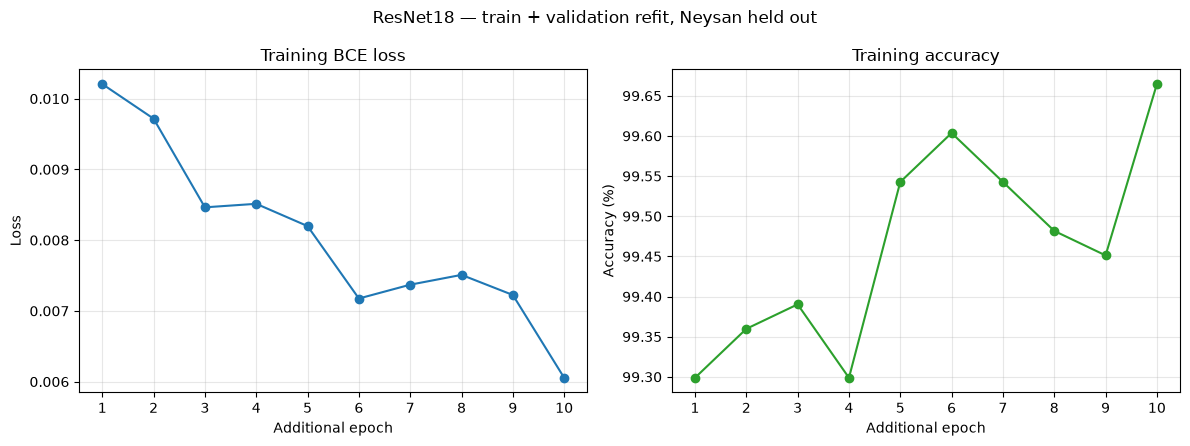

Figure saved: D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\neysan_experiment\trainval_refit\final_training_curves.png
Total training time: 75.3 minutes


In [10]:
import matplotlib.pyplot as plt

final_history = pd.read_csv(
    FINAL_DIR / "final_training_history.csv"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(
    final_history["epoch"],
    final_history["train_loss"],
    marker="o",
)
axes[0].set_title("Training BCE loss")
axes[0].set_ylabel("Loss")

axes[1].plot(
    final_history["epoch"],
    final_history["train_accuracy"] * 100,
    marker="o",
    color="tab:green",
)
axes[1].set_title("Training accuracy")
axes[1].set_ylabel("Accuracy (%)")

for ax in axes:
    ax.set_xlabel("Additional epoch")
    ax.set_xticks(final_history["epoch"])
    ax.grid(alpha=0.3)

fig.suptitle(
    "ResNet18 — train + validation refit, Neysan held out"
)
fig.tight_layout()

figure_path = FINAL_DIR / "final_training_curves.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved:", figure_path)
print(
    "Total training time:",
    f"{final_history['seconds'].sum() / 60:.1f} minutes",
)